In [ ]:
%pip install ultralytics
import ultralytics
ultralytics.checks()

Ultralytics 8.3.213 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 39.4/112.6 GB disk)


In [ ]:
!unzip /content/drive/MyDrive/rock-paper-scissors.v14i.yolov11.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-212_jpg.rf.1e8561703c71365c0fed5b3bf9ae055c.txt  
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-212_jpg.rf.6d343393e00bb5cdd53ba41620c2805d.txt  
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-212_jpg.rf.7653f90d0a71d91fb45908be2cfb2ef9.txt  
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-214_jpg.rf.14f2adf12c2c9bc458d9495b8ec61076.txt  
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-214_jpg.rf.6d5bc1bd3db6b53f0951763b33f8fe3c.txt  
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-214_jpg.rf.9fe36597c1505ea00935f4d1e1285ded.txt  
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-215_jpg.rf.323f75af9cc2a439a8ed0b738864b30c.txt  
  inflating: train/labels/Screen-Recording-2023-03-11-at-9_48_18-PM_mov-215_jpg.rf.7e7e0e3f1698

In [4]:
!yolo train model=yolo11m.pt data='/content/data.yaml' epochs=5 imgsz=640

Ultralytics 8.3.213 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11m.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretra

In [5]:
!yolo val model='/content/runs/detect/train/weights/best.pt' data='/content/data.yaml'

Ultralytics 8.3.213 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 125 layers, 20,032,345 parameters, 0 gradients, 67.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1493.1±358.0 MB/s, size: 30.4 KB)
val: Scanning /content/valid/labels.cache... 576 images, 238 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 576/576 11.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 36/36 2.3it/s 15.4s
                   all        576        400      0.726      0.787      0.803      0.561
                 Paper        132        139      0.669      0.719      0.735      0.462
                  Rock        121        141      0.731      0.867      0.831      0.599
              Scissors        116        120      0.779      0.775      0.843      0.622
Speed: 0.9ms preprocess, 22.8ms inference, 0.0ms loss, 1.0ms postprocess per image
Results saved to /content/runs/detect/val
💡 Learn more 

In [6]:
import cv2
from google.colab.patches import cv2_imshow

In [8]:
def show_image(image_path):
  image=cv2.imread(image_path)
  if image is None:
    print("Image not found")
    return
  cv2_imshow(image)

In [9]:
#inferencing with our trained model
!yolo predict model='/content/runs/detect/train/weights/best.pt' source='/content/train/images/0038_png.rf.767805c1e827d19bfc35f9e2bcdfab55.jpg'

Ultralytics 8.3.213 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11m summary (fused): 125 layers, 20,032,345 parameters, 0 gradients, 67.7 GFLOPs

image 1/1 /content/train/images/0038_png.rf.767805c1e827d19bfc35f9e2bcdfab55.jpg: 640x640 2 Scissorss, 36.9ms
Speed: 2.7ms preprocess, 36.9ms inference, 119.6ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/predict
💡 Learn more at https://docs.ultralytics.com/modes/predict


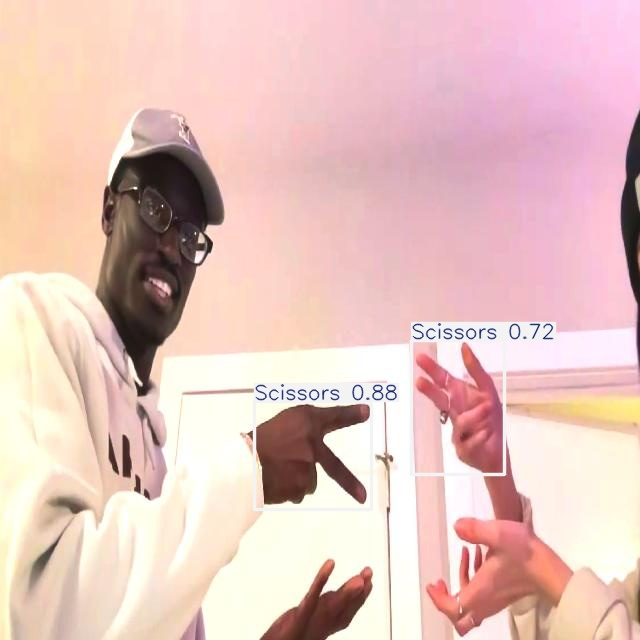

In [10]:
show_image('/content/runs/detect/predict/0038_png.rf.767805c1e827d19bfc35f9e2bcdfab55.jpg')

In [11]:
! yolo export model='/content/runs/detect/train/weights/best.pt' format=onnx

Ultralytics 8.3.213 🚀 Python-3.12.12 torch-2.8.0+cu126 CPU (Intel Xeon CPU @ 2.00GHz)
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
YOLO11m summary (fused): 125 layers, 20,032,345 parameters, 0 gradients, 67.7 GFLOPs

PyTorch: starting from '/content/runs/detect/train/weights/best.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 7, 8400) (38.6 MB)
requirements: Ultralytics requirements ['onnx>=1.12.0', 'onnxslim>=0.1.71', 'onnxruntime'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 2.4s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.1 opset 22...
ONNX: slimming with onnxslim 0.1.71...
ONNX: export success ✅ 5.9s, saved as '/content/runs/detect/train/weights/best.onnx' (76.7 MB)

Export complete (7.9s)
Results saved to /content/runs/detect/train/weights
Predict:         yol

In [12]:
!yolo export model=yolo11n.pt format=engine

WARNING ⚠️ TensorRT requires GPU export, automatically assigning device=0
Ultralytics 8.3.213 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
YOLO11n summary (fused): 100 layers, 2,616,248 parameters, 0 gradients, 6.5 GFLOPs

PyTorch: starting from 'yolo11n.pt' with input shape (1, 3, 640, 640) BCHW and output shape(s) (1, 84, 8400) (5.4 MB)
requirements: Ultralytics requirement ['onnxruntime-gpu'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 3.2s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


ONNX: starting export with onnx 1.19.1 opset 20...
ONNX: slimming with onnxslim 0.1.71...
ONNX: export success ✅ 4.7s, saved as 'yolo11n.onnx' (10.2 MB)
requirements: Ultralytics requirement ['tensorrt-cu12>7.0.0,!=10.1.0'] not found, attempting AutoUpdate...

requirements: AutoUpdate success ✅ 100.6s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


TensorRT: starting export wit

## Python Usage

In [13]:
from ultralytics import YOLO
model=YOLO('yolo11n.pt')
results=model.train(data='/content/data.yaml',epochs=1)
results=model.val()
results=model('/content/train/images/0038_png.rf.767805c1e827d19bfc35f9e2bcdfab55.jpg')


New https://pypi.org/project/ultralytics/8.3.214 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.213 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train2, nbs=64, nms=False, opset=None, optimize